In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.cloud import bigquery

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
PROJECT_ID = "nyc-taxi-analytics-1"

client = bigquery.Client(project=PROJECT_ID)

In [3]:
def run_query(query: str) -> pd.DataFrame:
    query_job = client.query(query)
    result = query_job.result()
    return result.to_dataframe()

In [5]:
query_outlier_sample = f"""
SELECT
    trip_id,
    pickup_year_month,
    pickup_hour,
    pickup_time_period,
    is_weekend,

    trip_distance,
    trip_duration_minutes,
    fare_amount,
    tip_amount,
    total_amount,
    fare_per_mile,
    tip_rate,

    is_trip_distance_outlier,
    is_trip_duration_outlier,
    is_fare_amount_outlier,
    is_total_amount_outlier,
    is_fare_per_mile_outlier,
    is_tip_rate_outlier,
    is_any_outlier

FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.vw_yellow_taxi_outlier_flags`
WHERE RAND() < 0.01
LIMIT 100000
"""

df_outlier = run_query(query_outlier_sample)
df_outlier.head()

,trip_id,pickup_year_month,pickup_hour,pickup_time_period,is_weekend,trip_distance,trip_duration_minutes,fare_amount,tip_amount,total_amount,fare_per_mile,tip_rate,is_trip_distance_outlier,is_trip_duration_outlier,is_fare_amount_outlier,is_total_amount_outlier,is_fare_per_mile_outlier,is_tip_rate_outlier,is_any_outlier
0,ff4402c29654128da85f1b963459333c,2023-03,22,Night,True,0.39,3,5.10,2.02,12.12,13.08,0.40,False,False,False,False,False,False,False
1,8b31ee395d6f5b26e8d565c009b7855a,2023-03,1,Late night,True,0.63,5,6.50,2.30,13.80,10.32,0.35,False,False,False,False,False,False,False
2,72004bcea7d1a640392aa00d5dd820df,2023-03,13,Midday,True,0.81,5,7.20,0.00,8.70,8.89,0.00,False,False,False,False,False,False,False
3,97fa053d416871f8de22deec1a714935,2023-03,8,Morning,True,0.80,5,7.20,2.24,13.44,9.00,0.31,False,False,False,False,False,False,False
4,8006ae16287dde400ccf5552f79f50fa,2023-03,12,Midday,True,1.09,4,7.20,2.24,13.44,6.61,0.31,False,False,False,False,False,False,False


In [6]:
outlier_summary = pd.DataFrame({
    "metric": [
        "trip_distance",
        "trip_duration",
        "fare_amount",
        "total_amount",
        "fare_per_mile",
        "tip_rate",
        "any_outlier"
    ],
    "outlier_count": [
        df_outlier["is_trip_distance_outlier"].sum(),
        df_outlier["is_trip_duration_outlier"].sum(),
        df_outlier["is_fare_amount_outlier"].sum(),
        df_outlier["is_total_amount_outlier"].sum(),
        df_outlier["is_fare_per_mile_outlier"].sum(),
        df_outlier["is_tip_rate_outlier"].sum(),
        df_outlier["is_any_outlier"].sum()
    ]
})

outlier_summary["outlier_percentage"] = (
    outlier_summary["outlier_count"] / len(df_outlier) * 100
).round(2)

outlier_summary

,metric,outlier_count,outlier_percentage
0,trip_distance,13212,13.21
1,trip_duration,5663,5.66
2,fare_amount,9889,9.89
3,total_amount,11382,11.38
4,fare_per_mile,4452,4.45
5,tip_rate,430,0.43
6,any_outlier,18645,18.64


/tmp/ipykernel_119734/1089698247.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


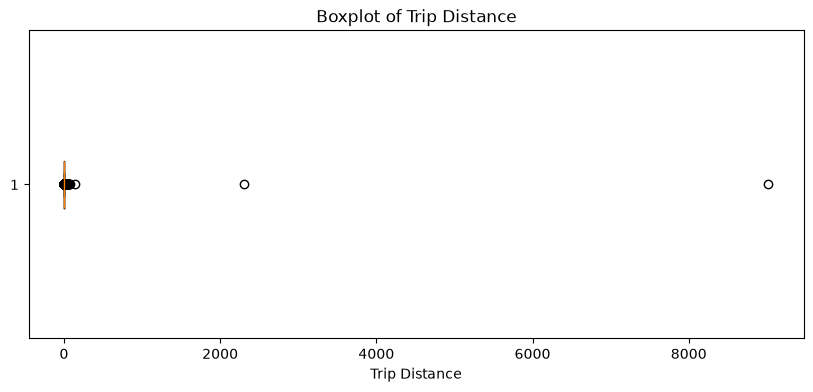

/tmp/ipykernel_119734/1089698247.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


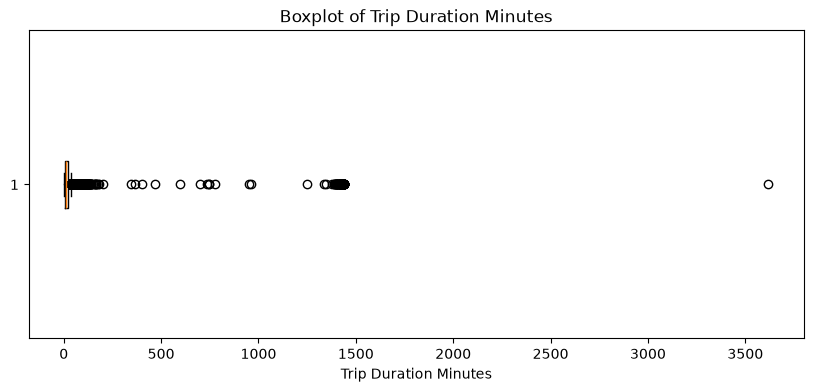

/tmp/ipykernel_119734/1089698247.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


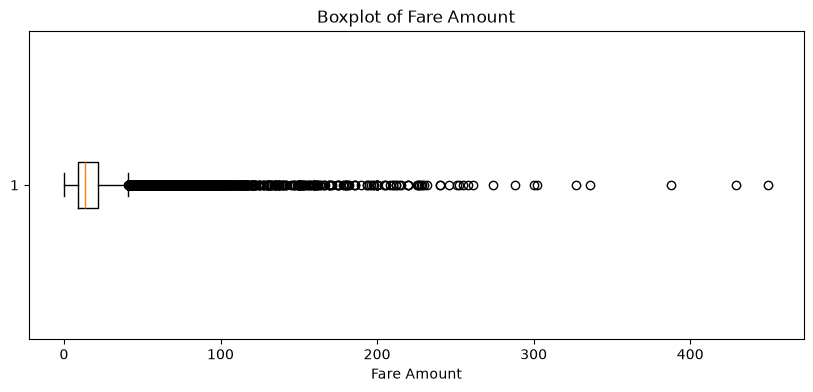

/tmp/ipykernel_119734/1089698247.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


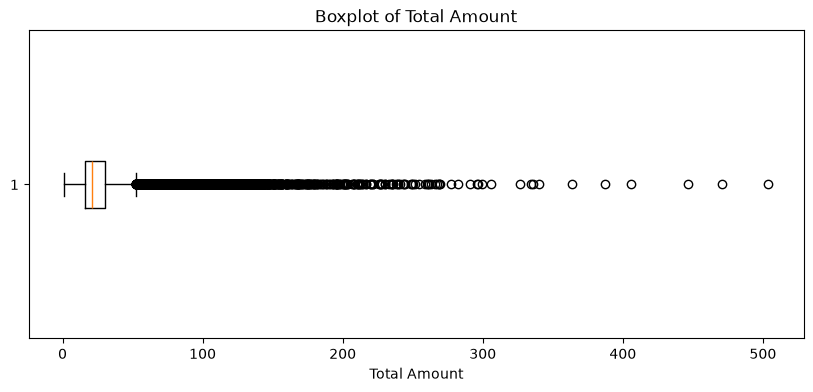

/tmp/ipykernel_119734/1089698247.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


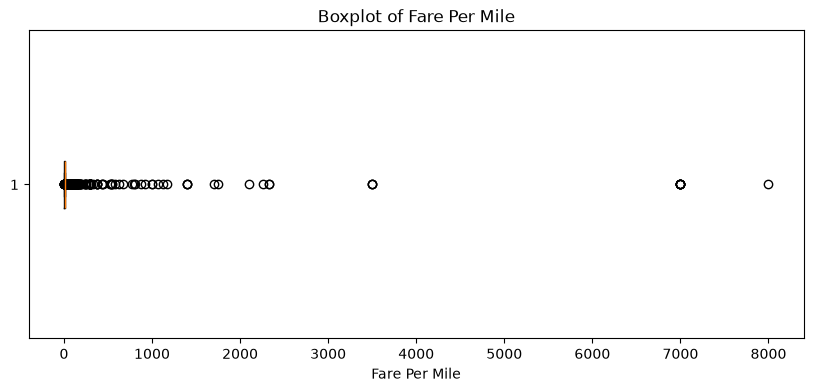

/tmp/ipykernel_119734/1089698247.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


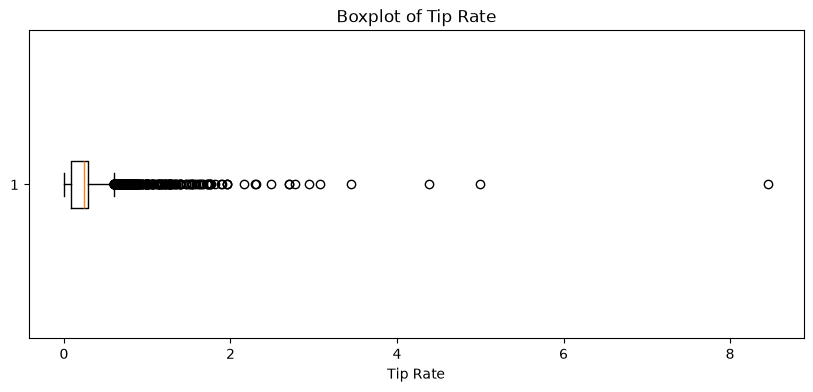

In [9]:
boxplot_columns = [
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "total_amount",
    "fare_per_mile",
    "tip_rate"
]

for column in boxplot_columns:
    plt.figure(figsize=(10, 4))

    plt.boxplot(
        df_outlier[column].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {column.replace('_', ' ').title()}")
    plt.xlabel(column.replace("_", " ").title())

    plt.show()

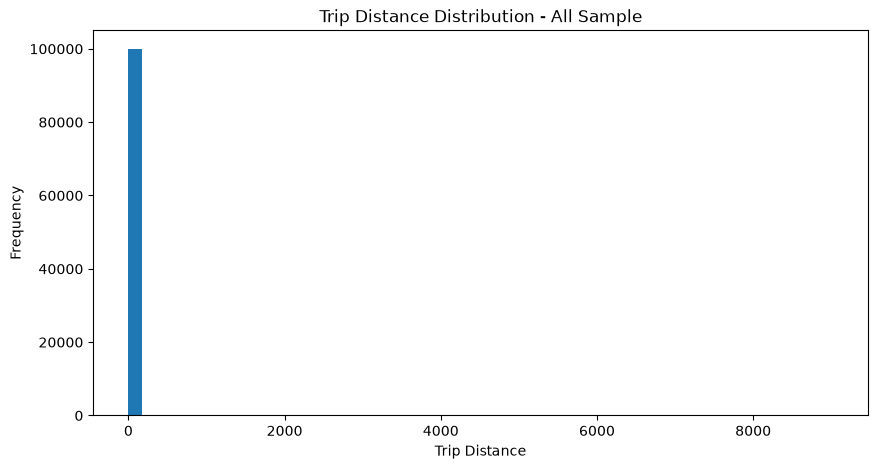

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(df_outlier["trip_distance"], bins=50)
plt.title("Trip Distance Distribution - All Sample")
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")
plt.show()

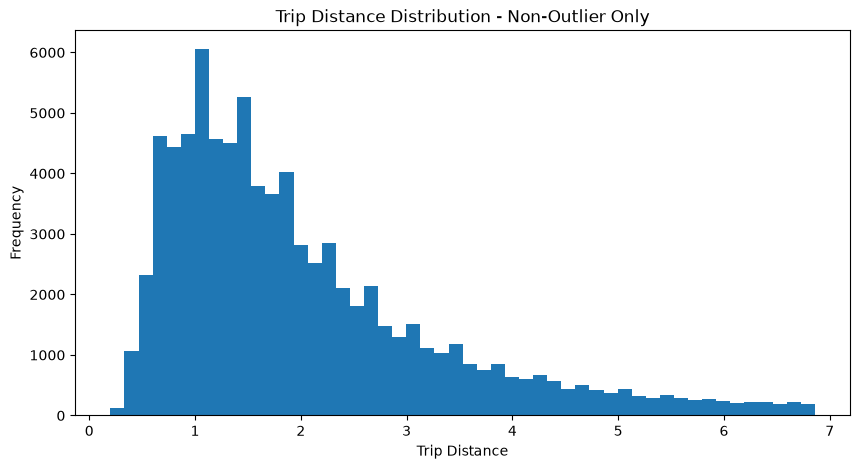

In [17]:
df_non_outlier = df_outlier[df_outlier["is_any_outlier"] == False]

plt.figure(figsize=(10, 5))
plt.hist(df_non_outlier["trip_distance"], bins=50)
plt.title("Trip Distance Distribution - Non-Outlier Only")
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")
plt.show()

In [12]:
comparison = (
    df_outlier
    .groupby("is_any_outlier", as_index=False)
    .agg(
        total_trips=("trip_id", "count"),
        avg_trip_distance=("trip_distance", "mean"),
        avg_trip_duration=("trip_duration_minutes", "mean"),
        avg_fare_amount=("fare_amount", "mean"),
        avg_tip_amount=("tip_amount", "mean"),
        avg_total_amount=("total_amount", "mean"),
        avg_fare_per_mile=("fare_per_mile", "mean"),
        avg_tip_rate=("tip_rate", "mean")
    )
)

comparison["group"] = comparison["is_any_outlier"].map({
    True: "Outlier",
    False: "Non-Outlier"
})

comparison

,is_any_outlier,total_trips,avg_trip_distance,avg_trip_duration,avg_fare_amount,avg_tip_amount,avg_total_amount,avg_fare_per_mile,avg_tip_rate,group
0,False,81355,2.01,12.62,13.79,2.70,21.22,7.73,0.21,Non-Outlier
1,True,18645,10.49,37.29,44.67,7.52,61.27,14.20,0.19,Outlier


Dapat disimpulkan bahwa sebagian kecil trip terdeteksi sebagai outlier pada variabel trip_distance, trip_duration, total_amount, fare_per_mile, dan tip_rate. Outlier tersebut menunjukkan adanya perjalanan dengan nilai ekstrem dibandingkan distribusi mayoritas data. Namun, karena data telah melewati proses cleaning dasar seperti validasi tanggal, durasi, jarak, payment type, dan amount positif, outlier tidak langsung dianggap sebagai data salah.

Dalam analisis bisnis utama, outlier sebaiknya tetap disimpan dengan flag agar dapat dianalisis secara terpisah. Untuk dashboard ringkasan, disarankan menyediakan filter outlier agar user dapat membandingkan performa dengan dan tanpa nilai ekstrem.